# Notebook 87 — per-frame Hough internals on representative worst frames

This notebook audits representative worst frames directly at the Hough-internals level: exact saved MATLAB peaks/weights/selected median, current Python peak stream, weighted-median crossing, and Python corrected accumulator/profile.

In [1]:
from pathlib import Path
import subprocess
import sys
from IPython.display import Markdown, Image, display

ROOT = Path.cwd().resolve()
if not (ROOT / 'scripts').exists():
    ROOT = ROOT.parent
SCRIPT = ROOT / 'scripts' / 'evaluate_hough_internals_worst_frames.py'
OUT = ROOT / 'results' / 'notebook87_hough_internals_worst_frames'
print(f'Project root: {ROOT}')
print(f'Script: {SCRIPT}')
print(f'Output directory: {OUT}')

Project root: /Users/grosbedou/PycharmProjects/NDORMS
Script: /Users/grosbedou/PycharmProjects/NDORMS/scripts/evaluate_hough_internals_worst_frames.py
Output directory: /Users/grosbedou/PycharmProjects/NDORMS/results/notebook87_hough_internals_worst_frames


In [2]:
completed = subprocess.run([sys.executable, str(SCRIPT)], check=True)
completed

Auditing aligned frame 71 (python frame 72)
Auditing aligned frame 96 (python frame 97)
Auditing aligned frame 118 (python frame 119)
Auditing aligned frame 437 (python frame 438)
Auditing aligned frame 613 (python frame 614)
Auditing aligned frame 730 (python frame 731)
Auditing aligned frame 882 (python frame 883)
Auditing aligned frame 910 (python frame 911)
Auditing aligned frame 980 (python frame 981)
Auditing aligned frame 1141 (python frame 1142)
Auditing aligned frame 1171 (python frame 1172)
Auditing aligned frame 1234 (python frame 1235)
Auditing aligned frame 1414 (python frame 1415)
Auditing aligned frame 2215 (python frame 2216)
Auditing aligned frame 2520 (python frame 2521)
Auditing aligned frame 2553 (python frame 2554)
# Notebook 87 — per-frame Hough internals on representative worst frames

Audited 16 representative worst aligned frames chosen from the full-sequence raw-alpha error ranking (minimum spacing 20 frames).

This notebook compares exact saved MATLAB Hough p

CompletedProcess(args=['/Library/Developer/CommandLineTools/usr/bin/python3', '/Users/grosbedou/PycharmProjects/NDORMS/scripts/evaluate_hough_internals_worst_frames.py'], returncode=0)

In [3]:
display(Markdown((OUT / 'notebook87_summary.md').read_text()))

# Notebook 87 — per-frame Hough internals on representative worst frames

Audited 16 representative worst aligned frames chosen from the full-sequence raw-alpha error ranking (minimum spacing 20 frames).

This notebook compares exact saved MATLAB Hough peaks/weights/selected median against the current Python per-frame Hough output on the same frames.

## Ground-truth boundary

- Exact MATLAB saved peak angles, weights, peak lines, and selected weighted-median alpha are available in the local UTT export.
- Exact MATLAB full fascicle Hough accumulator/profile is not present in the saved exports, and no local MATLAB/Octave runtime is available here to regenerate it.
- So the per-frame accumulator heatmap/profile panels are exact Python-side internals with MATLAB peaks overlaid, not a full MATLAB-vs-Python accumulator matrix diff.

## Key findings

- On these representative worst frames, MATLAB alpha is reconstructed from the saved MATLAB peaks with max absolute error 0.000000 deg, so the MATLAB peak/weight reference is self-consistent.
- Python still contains a peak within 2 deg of MATLAB on 13/16 representative worst frames.
- Yet the raw Python alpha is still >5 deg wrong on 13/16 frames even though such a close candidate exists.
- Bias-mode counts: lower-angle overweight 0, higher-angle overweight 13, candidate absent 3.

## Interpretation

- When a MATLAB-like Python peak is present but the Python weighted median still misses badly, the implementation of weighted median itself is not the main issue.
- The failure is that the Python candidate-family weight distribution crosses 0.5 on the wrong side before the MATLAB-like peak can dominate.
- Frames where the MATLAB-like peak is absent point further upstream to candidate generation / mask construction rather than aggregation logic.

- Selected-frame summary CSV: `/Users/grosbedou/PycharmProjects/NDORMS/results/notebook87_hough_internals_worst_frames/selected_worst_frame_summary.csv`
- Bias mode counts CSV: `/Users/grosbedou/PycharmProjects/NDORMS/results/notebook87_hough_internals_worst_frames/bias_mode_counts.csv`
- Python Hough profile CSV: `/Users/grosbedou/PycharmProjects/NDORMS/results/notebook87_hough_internals_worst_frames/python_hough_profiles_long.csv`
- Representative frame list: `/Users/grosbedou/PycharmProjects/NDORMS/results/notebook87_hough_internals_worst_frames/representative_frames.json`
- Overview plot: `/Users/grosbedou/PycharmProjects/NDORMS/results/notebook87_hough_internals_worst_frames/hough_internals_overview.png`
- Per-frame debug panels: `/Users/grosbedou/PycharmProjects/NDORMS/results/notebook87_hough_internals_worst_frames/frame_debug`


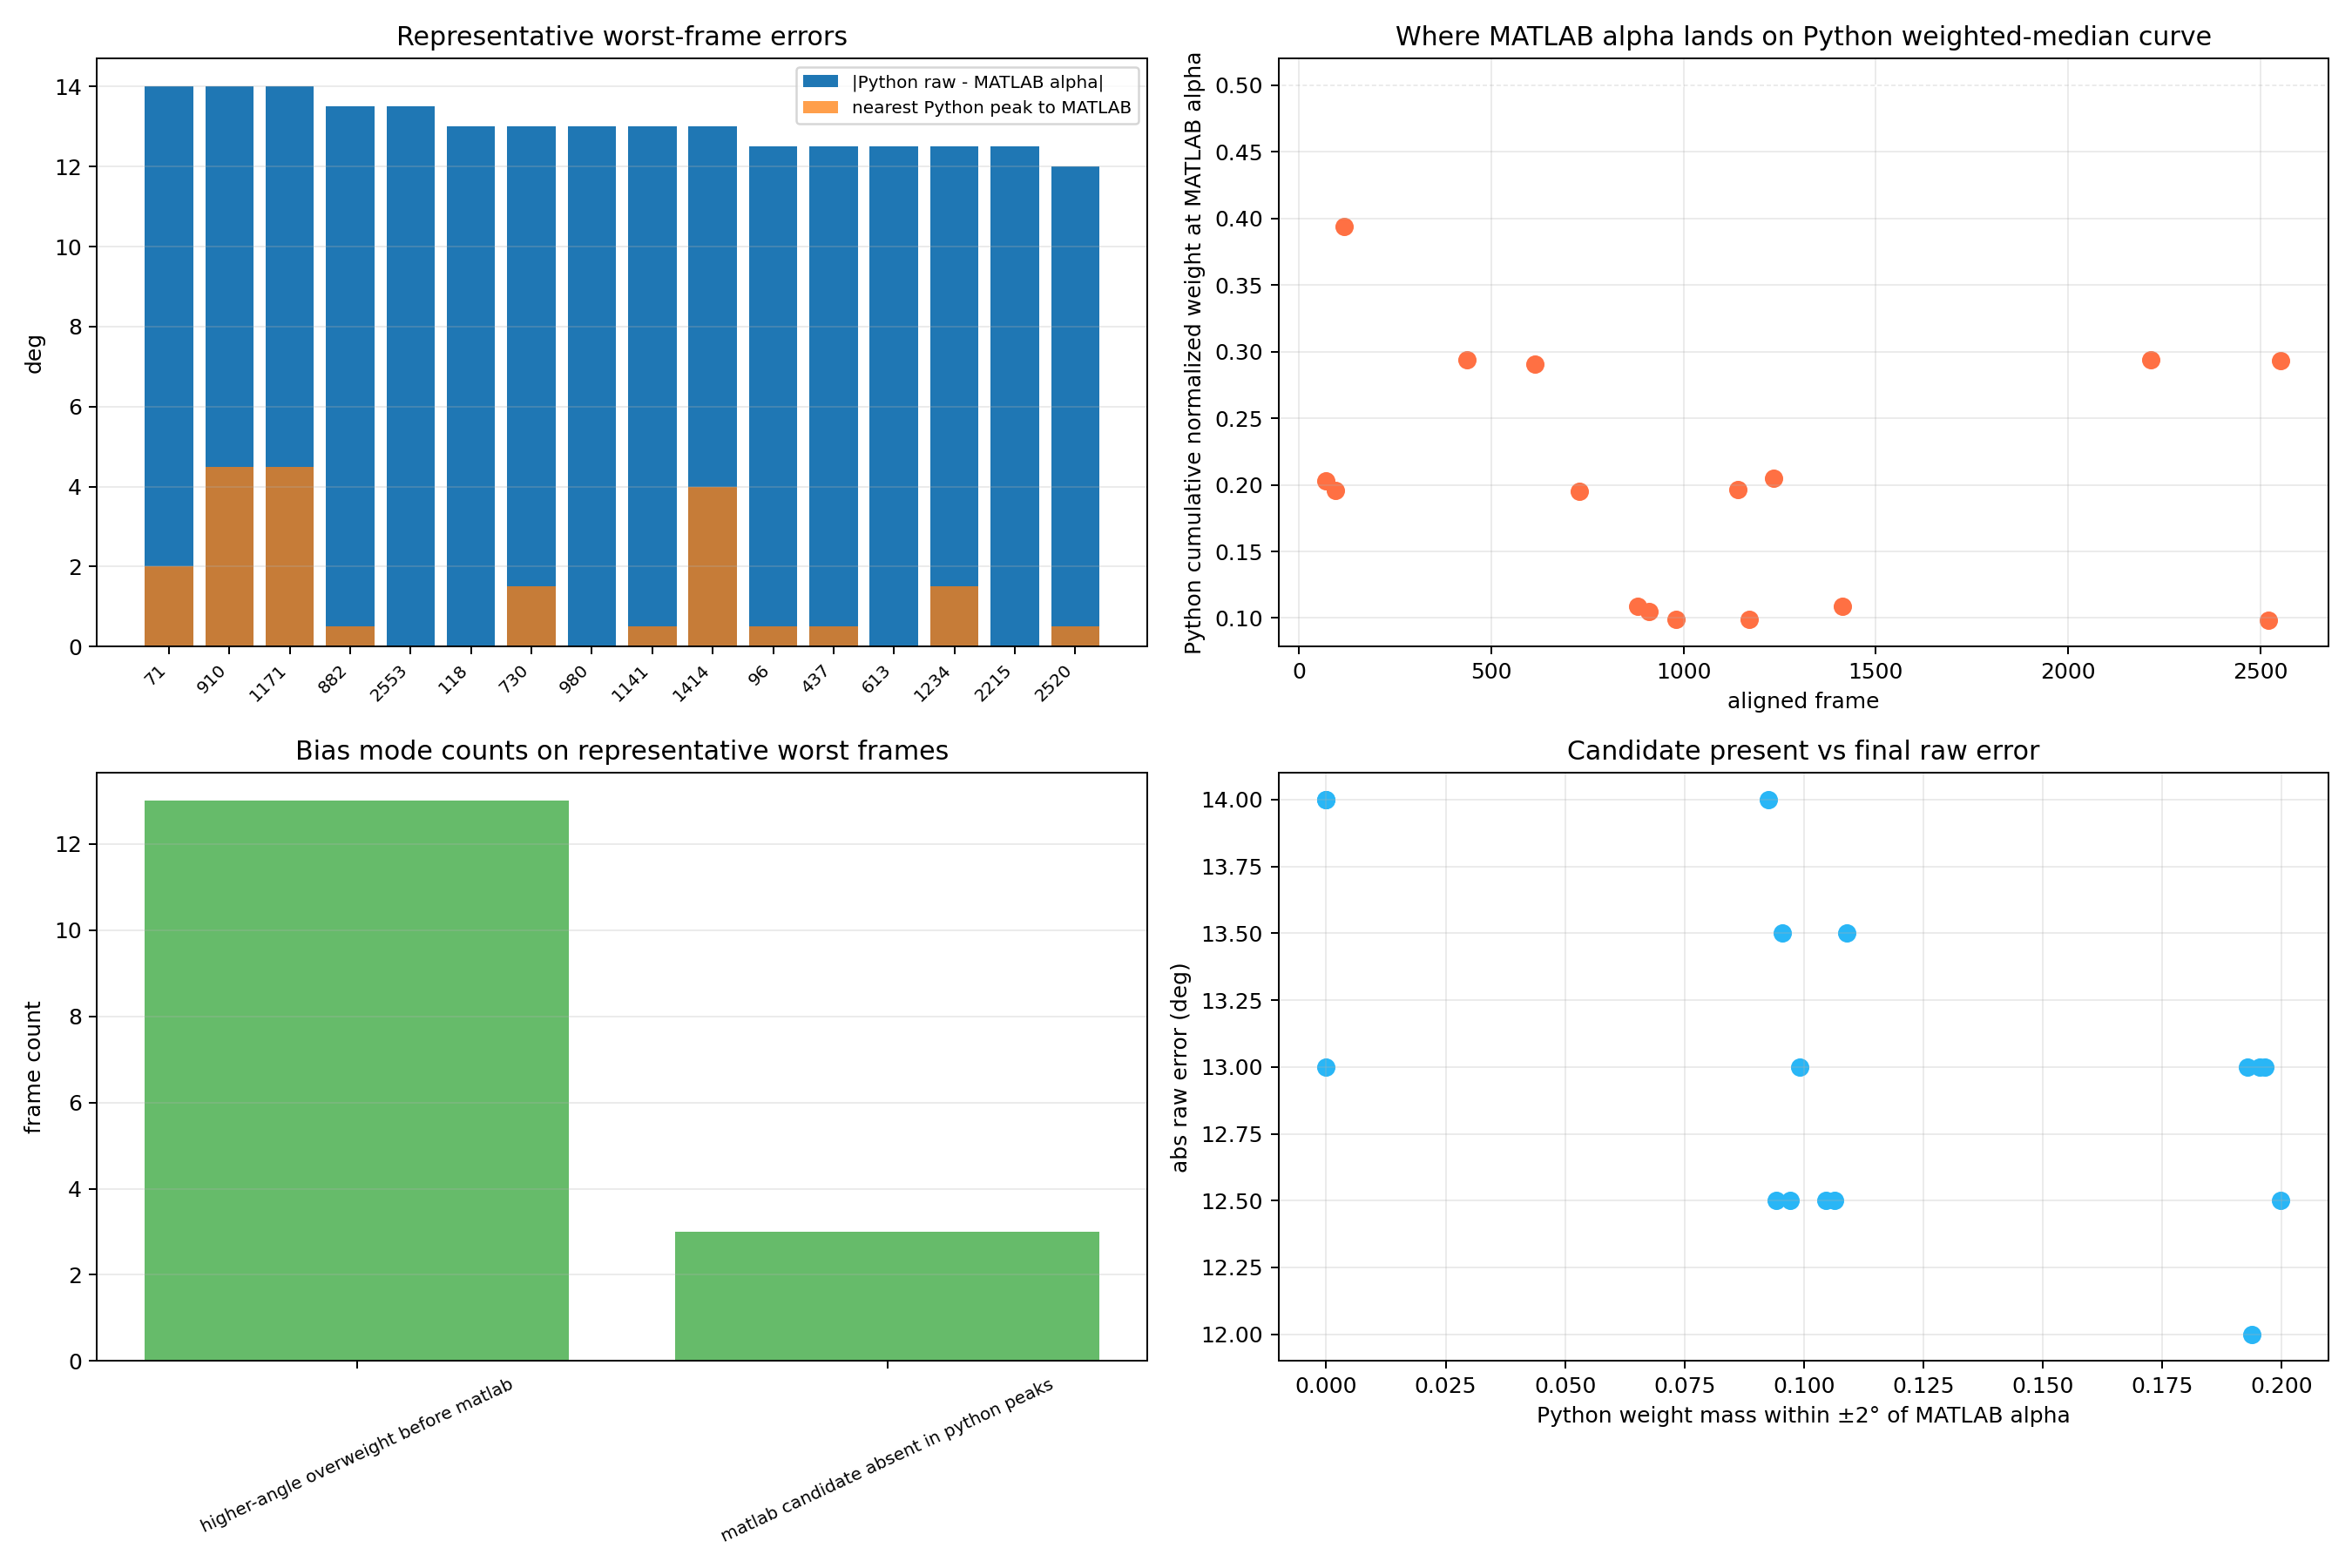

In [4]:
display(Image(filename=str(OUT / 'hough_internals_overview.png')))